In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from tqdm import tqdm
import random
import collections
from collections import deque
import cvxpy as cp
from datetime import datetime


In [2]:
cwd = Path.cwd()
if (cwd / "data").exists() and (cwd / "Day-Ahead_RO.ipynb").exists():
    SCHED_ROOT = cwd
elif (cwd / "ESS_Scheduling" / "data").exists():
    SCHED_ROOT = cwd / "ESS_Scheduling"
else:
    raise FileNotFoundError("ESS scheduling root directory를 찾지 못했습니다.")

DATA_DIR = SCHED_ROOT / "data"
RESULT_DIR = SCHED_ROOT / "Day-ahead_result"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

FACILITY_ID = 1

def align_load_units(frame):
    frame = frame.copy()
    actual_med = frame["actual"].abs().replace(0, np.nan).median()
    pred24_med = frame["pred_24_step"].abs().replace(0, np.nan).median()

    if pd.notna(actual_med) and pd.notna(pred24_med) and actual_med > 0 and pred24_med > 0:
        ratio = pred24_med / actual_med

        if 900 <= ratio <= 1100:
            frame["actual"] = frame["actual"] * 1000
            if "pred_1_step" in frame.columns:
                frame["pred_1_step"] = frame["pred_1_step"] * 1000
        elif 0.0009 <= ratio <= 0.0011:
            frame["pred_24_step"] = frame["pred_24_step"] / 1000

    return frame

def load_facility_forecast(data_dir, facility_id):
    data_path = Path(data_dir) / f"load_{facility_id}.csv"
    if not data_path.exists():
        raise FileNotFoundError(f"시설 파일을 찾지 못했습니다: {data_path}")

    frame = pd.read_csv(data_path)
    frame["timestamp"] = pd.to_datetime(frame["timestamp"])
    frame = align_load_units(frame)
    frame["season_slot"] = frame["season"] + "/" + frame["slot"]
    frame["month"] = frame["timestamp"].dt.to_period("M")
    return frame.sort_values("timestamp").reset_index(drop=True), data_path

df, data_path = load_facility_forecast(DATA_DIR, FACILITY_ID)
pd.Series({
    "sched_root": str(SCHED_ROOT),
    "data_dir": str(DATA_DIR),
    "result_dir": str(RESULT_DIR),
    "facility_id": FACILITY_ID,
    "rows": len(df),
})


sched_root         /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling
data_dir       /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
result_dir     /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
facility_id                                                    1
rows                                                       11784
dtype: object

In [3]:
def round_to_nearest_10(value, min_value=10):
    rounded = int(np.round(value / 10.0) * 10)
    return max(min_value, rounded)

def estimate_capacity_from_daily_max_usage(load_kw, timestamps, round_unit=10, min_capacity=10):
    temp = pd.DataFrame({
        "timestamp": pd.to_datetime(timestamps),
        "load_kw": pd.to_numeric(load_kw, errors="coerce"),
    })
    daily_total_usage = temp.groupby(temp["timestamp"].dt.date)["load_kw"].sum()
    max_daily_usage = float(daily_total_usage.max())
    capacity_kwh = max(min_capacity, int(round_unit * np.round(max_daily_usage / round_unit)))
    return capacity_kwh, max_daily_usage, daily_total_usage

raw_df = df[["timestamp", "actual"]].rename(columns={"actual": "load"}).copy()
raw_df = raw_df.sort_values("timestamp").set_index("timestamp")

capacity, max_daily_usage, daily_total_usage = estimate_capacity_from_daily_max_usage(
    df["actual"], df["timestamp"]
)

pd.Series({
    "facility_id": FACILITY_ID,
    "data_path": str(data_path),
    "rows": len(df),
    "actual_mean_kW": df["actual"].mean(),
    "pred_24_step_mean_kW": df["pred_24_step"].mean(),
    "max_daily_usage_kWh": max_daily_usage,
    "capacity_kWh": capacity,
})


facility_id                                                             1
data_path               /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
rows                                                                11784
actual_mean_kW                                                 150.486943
pred_24_step_mean_kW                                           151.395268
max_daily_usage_kWh                                               4481.12
capacity_kWh                                                         4480
dtype: object

# Battery Degradation

In [4]:
WEAR_OUT_UNIT_COST = 150000 / (6000 * 2 * 0.8 * 0.95)

def wear_out_cost(x):
    return WEAR_OUT_UNIT_COST * (cp.abs(x) / (2 * 0.8))

def wear_out_cost_numeric(x):
    x = np.asarray(x, dtype=float)
    return WEAR_OUT_UNIT_COST * (np.abs(x) / (2 * 0.8))


## Robust + Stochastic

In [5]:
from scipy.stats import truncnorm

def init_error_history(season_slots):
    unique_slots = sorted(pd.Series(season_slots).dropna().unique())
    return {slot: [] for slot in unique_slots}

def get_error_stats(error_history, min_std=0.0):
    error_stats = {}
    for slot, values in error_history.items():
        if len(values) == 0:
            error_stats[slot] = (0.0, 0.0)
        elif len(values) == 1:
            error_stats[slot] = (float(values[0]), 0.0)
        else:
            mean_err = float(np.mean(values))
            std_err = float(max(np.std(values, ddof=1), min_std))
            error_stats[slot] = (mean_err, std_err)
    return error_stats

def update_error_history(error_history, actual_load, forecast_load, season_slots):
    for actual, forecast, slot in zip(actual_load, forecast_load, season_slots):
        if pd.isna(actual) or pd.isna(forecast):
            continue
        denom = max(abs(float(forecast)), 1e-6)
        abs_pct_error = abs(float(actual) - float(forecast)) / denom * 100
        error_history.setdefault(slot, []).append(abs_pct_error)
    return error_history

def generate_robust_load_scenarios(load, season_slots, error_stats, num_scenarios=10, seed=None):
    rng = np.random.default_rng(seed)
    load = np.asarray(load, dtype=float)
    scenarios = np.zeros((num_scenarios, len(load)))

    for s in range(num_scenarios):
        for t, season_slot in enumerate(season_slots):
            mean_err, std_err = error_stats.get(season_slot, (0.0, 0.0))

            if std_err <= 0:
                delta = max(mean_err, 0.0) / 100
            else:
                a = (0 - mean_err) / std_err
                sampled_error = truncnorm.rvs(a, np.inf, loc=mean_err, scale=std_err, random_state=rng)
                delta = max(sampled_error, 0.0) / 100

            scenarios[s, t] = load[t] * (1 + delta)

    return scenarios

error_history = init_error_history(df["season_slot"])
initial_error_stats = get_error_stats(error_history)
pd.Series(initial_error_stats).head()


spring/fall/high      (0.0, 0.0)
spring/fall/low       (0.0, 0.0)
spring/fall/middle    (0.0, 0.0)
summer/high           (0.0, 0.0)
summer/low            (0.0, 0.0)
dtype: object

## 피크에 따른 계약전력 반영

In [6]:
df = df.sort_values("timestamp").reset_index(drop=True).copy()

max_rate = 10  # 한 시간 최대 충/방전 가능 용량 (kW)
soc_min, soc_max = 0.1, 0.9
initial_soc = 0.5
current_peak = 0.0
lambda_peak = 7470

step = 24
num_days = (len(df) + step - 1) // step
num_scenarios = 10
wearout_weight = 10

error_history = init_error_history(df["season_slot"])
x_all = []
soc_total = []
adaptive_error_mean = []
adaptive_error_std = []
realized_schedule = []
schedule_on_forecast = []
day_logs = []

for day_idx in range(num_days):
    start = day_idx * step
    end = min(start + step, len(df))
    day = df.iloc[start:end].copy()

    if day.empty:
        continue

    forecast_load = day["pred_24_step"].to_numpy(dtype=float)
    actual_load = day["actual"].to_numpy(dtype=float)
    price = day["price"].to_numpy(dtype=float)
    season_slots = day["season_slot"].to_list()

    day_error_stats = get_error_stats(error_history)
    scenario_loads = generate_robust_load_scenarios(
        forecast_load, season_slots, day_error_stats, num_scenarios=num_scenarios, seed=42 + day_idx
    )

    horizon = len(day)
    x = cp.Variable(horizon)
    soc = cp.Variable(horizon)

    scenario_costs = [
        cp.sum(cp.multiply(price, scenario_loads[s] + max_rate * x))
        for s in range(num_scenarios)
    ]
    energy_cost = sum(scenario_costs) / num_scenarios
    wear_cost = cp.sum(wear_out_cost(x)) * wearout_weight

    if current_peak == 0:
        peak_terms = [
            cp.max(scenario_loads[s] + max_rate * x) * lambda_peak
            for s in range(num_scenarios)
        ]
    else:
        peak_terms = [
            cp.pos(cp.max(scenario_loads[s] + max_rate * x) - current_peak) * lambda_peak
            for s in range(num_scenarios)
        ]
    peak_penalty = sum(peak_terms) / num_scenarios

    objective = cp.Minimize(energy_cost + wear_cost + peak_penalty)

    constraints = [
        x >= -0.95,
        x <= 0.95,
        soc[0] == initial_soc + (max_rate * x[0]) / capacity,
        soc[1:] == soc[:-1] + (max_rate * x[1:]) / capacity,
        soc >= soc_min,
        soc <= soc_max,
        cp.sum(x) == 0,
    ]

    for s in range(num_scenarios):
        constraints.append(scenario_loads[s] + max_rate * x >= 0)

    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.ECOS, warm_start=True, verbose=False)
    except Exception:
        prob.solve(solver=cp.SCS, warm_start=True, verbose=False)

    if x.value is None or soc.value is None:
        raise RuntimeError(f"optimization failed for day_idx={day_idx}")

    x_val = np.asarray(x.value, dtype=float).reshape(-1)
    soc_val = np.asarray(soc.value, dtype=float).reshape(-1)

    scheduled_load = forecast_load + max_rate * x_val
    realized_load = actual_load + max_rate * x_val

    slot_error_mean = np.array([day_error_stats.get(slot, (0.0, 0.0))[0] for slot in season_slots], dtype=float)
    slot_error_std = np.array([day_error_stats.get(slot, (0.0, 0.0))[1] for slot in season_slots], dtype=float)

    x_all.extend(x_val.tolist())
    soc_total.extend(soc_val.tolist())
    adaptive_error_mean.extend(slot_error_mean.tolist())
    adaptive_error_std.extend(slot_error_std.tolist())
    realized_schedule.extend(realized_load.tolist())
    schedule_on_forecast.extend(scheduled_load.tolist())

    current_peak = max(current_peak, float(np.max(realized_load)))

    error_history = update_error_history(error_history, actual_load, forecast_load, season_slots)
    updated_error_stats = get_error_stats(error_history)

    next_day_slots = season_slots
    next_day_error_mean = np.array([updated_error_stats.get(slot, (0.0, 0.0))[0] for slot in next_day_slots], dtype=float)

    day_logs.append({
        "day_idx": day_idx,
        "date": day["timestamp"].iloc[0].date(),
        "capacity_kWh": capacity,
        "forecast_mean_kW": float(np.mean(forecast_load)),
        "actual_mean_kW": float(np.mean(actual_load)),
        "mean_error_pct_before_update": float(np.mean(slot_error_mean)) if len(slot_error_mean) else 0.0,
        "mean_error_pct_after_update": float(np.mean(next_day_error_mean)) if len(next_day_error_mean) else 0.0,
        "realized_peak_kW": float(np.max(realized_load)),
        "current_peak_kW": float(current_peak),
    })

x_series = pd.Series(x_all)
soc_series = pd.Series(soc_total)
wear_out_total = wear_out_cost_numeric(x_series.values).sum()

proposed_result = df[["timestamp", "month", "actual", "pred_24_step", "price", "season", "slot", "season_slot"]].copy()
proposed_result = proposed_result.rename(columns={"actual": "real"})
proposed_result["capacity"] = capacity
proposed_result["x"] = x_series.values
proposed_result["soc"] = soc_series.values
proposed_result["adaptive_error_mean_pct"] = adaptive_error_mean
proposed_result["adaptive_error_std_pct"] = adaptive_error_std
proposed_result["result"] = realized_schedule
proposed_result["schedule"] = schedule_on_forecast

day_summary = pd.DataFrame(day_logs)

pd.Series({
    "facility_id": FACILITY_ID,
    "capacity_kWh": capacity,
    "wear_out_total": wear_out_total,
    "final_peak_kW": current_peak,
    "avg_adaptive_error_pct": float(np.mean(adaptive_error_mean)) if adaptive_error_mean else 0.0,
})


/home/teedlab/miniconda3/envs/cap_ESS/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


facility_id                   1.000000
capacity_kWh               4480.000000
wear_out_total            80200.691776
final_peak_kW               200.605413
avg_adaptive_error_pct        5.957893
dtype: float64

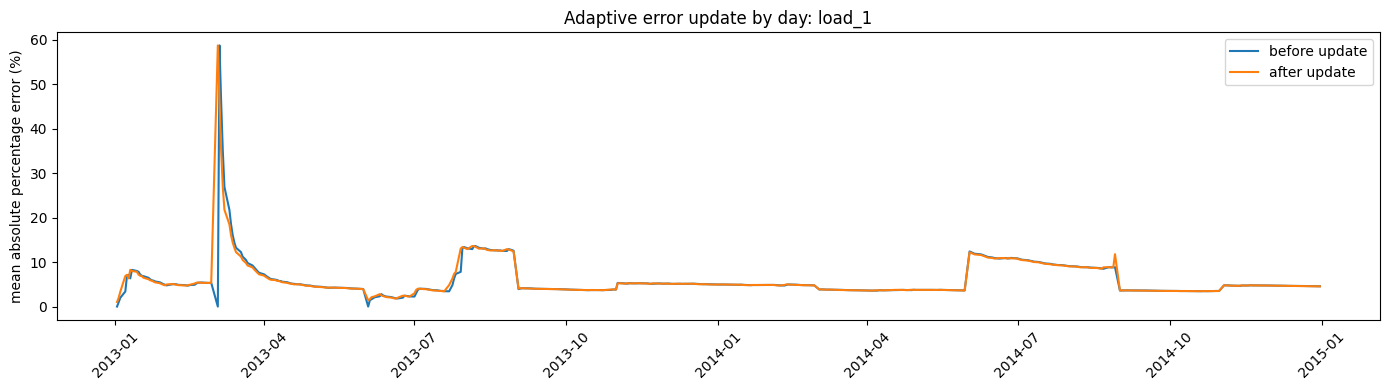

,timestamp,month,real,pred_24_step,price,season,slot,season_slot,capacity,x,soc,adaptive_error_mean_pct,adaptive_error_std_pct,result,schedule
0,2013-01-02 00:00:00,2013-01,175.574,175.14306,112.2,winter,low,winter/low,4480,-0.135975,0.499696,0.0,0.0,174.214249,173.783309
1,2013-01-02 01:00:00,2013-01,176.792,178.36294,112.2,winter,low,winter/low,4480,-0.457963,0.498674,0.0,0.0,172.212369,173.783309
2,2013-01-02 02:00:00,2013-01,178.066,181.19948,112.2,winter,low,winter/low,4480,-0.741617,0.497019,0.0,0.0,170.649829,173.783309
3,2013-01-02 03:00:00,2013-01,185.388,183.15200,112.2,winter,low,winter/low,4480,-0.936869,0.494928,0.0,0.0,176.019308,173.783308
4,2013-01-02 04:00:00,2013-01,186.466,183.28331,112.2,winter,low,winter/low,4480,-0.950000,0.492807,0.0,0.0,176.965999,173.783309


In [7]:
day_summary.head()

plt.figure(figsize=(14, 4))
plt.plot(day_summary["date"], day_summary["mean_error_pct_before_update"], label="before update")
plt.plot(day_summary["date"], day_summary["mean_error_pct_after_update"], label="after update")
plt.title(f"Adaptive error update by day: load_{FACILITY_ID}")
plt.ylabel("mean absolute percentage error (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

proposed_result.head()


In [8]:
def run_adaptive_day_ahead_schedule(
    facility_id,
    data_dir=DATA_DIR,
    max_rate=10,
    soc_min=0.1,
    soc_max=0.9,
    initial_soc=0.5,
    lambda_peak=7470,
    num_scenarios=10,
    wearout_weight=10,
    seed_base=42,
):
    facility_df, facility_path = load_facility_forecast(data_dir, facility_id)
    facility_df = facility_df.sort_values("timestamp").reset_index(drop=True).copy()

    capacity_kwh, max_daily_usage_kwh, _ = estimate_capacity_from_daily_max_usage(
        facility_df["actual"], facility_df["timestamp"]
    )

    error_history = init_error_history(facility_df["season_slot"])
    current_peak = 0.0
    step = 24
    num_days = (len(facility_df) + step - 1) // step

    x_all = []
    soc_total = []
    adaptive_error_mean = []
    adaptive_error_std = []
    realized_schedule = []
    schedule_on_forecast = []
    day_logs = []

    for day_idx in range(num_days):
        start = day_idx * step
        end = min(start + step, len(facility_df))
        day = facility_df.iloc[start:end].copy()

        if day.empty:
            continue

        forecast_load = day["pred_24_step"].to_numpy(dtype=float)
        actual_load = day["actual"].to_numpy(dtype=float)
        price = day["price"].to_numpy(dtype=float)
        season_slots = day["season_slot"].to_list()

        day_error_stats = get_error_stats(error_history)
        scenario_loads = generate_robust_load_scenarios(
            forecast_load,
            season_slots,
            day_error_stats,
            num_scenarios=num_scenarios,
            seed=seed_base + day_idx,
        )

        horizon = len(day)
        x = cp.Variable(horizon)
        soc = cp.Variable(horizon)

        scenario_costs = [
            cp.sum(cp.multiply(price, scenario_loads[s] + max_rate * x))
            for s in range(num_scenarios)
        ]
        energy_cost = sum(scenario_costs) / num_scenarios
        wear_cost = cp.sum(wear_out_cost(x)) * wearout_weight

        if current_peak == 0:
            peak_terms = [
                cp.max(scenario_loads[s] + max_rate * x) * lambda_peak
                for s in range(num_scenarios)
            ]
        else:
            peak_terms = [
                cp.pos(cp.max(scenario_loads[s] + max_rate * x) - current_peak) * lambda_peak
                for s in range(num_scenarios)
            ]
        peak_penalty = sum(peak_terms) / num_scenarios

        objective = cp.Minimize(energy_cost + wear_cost + peak_penalty)

        constraints = [
            x >= -0.95,
            x <= 0.95,
            soc[0] == initial_soc + (max_rate * x[0]) / capacity_kwh,
            soc[1:] == soc[:-1] + (max_rate * x[1:]) / capacity_kwh,
            soc >= soc_min,
            soc <= soc_max,
            cp.sum(x) == 0,
        ]

        for s in range(num_scenarios):
            constraints.append(scenario_loads[s] + max_rate * x >= 0)

        prob = cp.Problem(objective, constraints)

        try:
            prob.solve(solver=cp.ECOS, warm_start=True, verbose=False)
        except Exception:
            prob.solve(solver=cp.SCS, warm_start=True, verbose=False)

        if x.value is None or soc.value is None:
            raise RuntimeError(f"optimization failed for facility_id={facility_id}, day_idx={day_idx}")

        x_val = np.asarray(x.value, dtype=float).reshape(-1)
        soc_val = np.asarray(soc.value, dtype=float).reshape(-1)

        scheduled_load = forecast_load + max_rate * x_val
        realized_load = actual_load + max_rate * x_val

        slot_error_mean = np.array(
            [day_error_stats.get(slot, (0.0, 0.0))[0] for slot in season_slots],
            dtype=float,
        )
        slot_error_std = np.array(
            [day_error_stats.get(slot, (0.0, 0.0))[1] for slot in season_slots],
            dtype=float,
        )

        x_all.extend(x_val.tolist())
        soc_total.extend(soc_val.tolist())
        adaptive_error_mean.extend(slot_error_mean.tolist())
        adaptive_error_std.extend(slot_error_std.tolist())
        realized_schedule.extend(realized_load.tolist())
        schedule_on_forecast.extend(scheduled_load.tolist())

        current_peak = max(current_peak, float(np.max(realized_load)))

        error_history = update_error_history(error_history, actual_load, forecast_load, season_slots)
        updated_error_stats = get_error_stats(error_history)
        next_day_error_mean = np.array(
            [updated_error_stats.get(slot, (0.0, 0.0))[0] for slot in season_slots],
            dtype=float,
        )

        day_logs.append({
            "facility_id": facility_id,
            "day_idx": day_idx,
            "date": day["timestamp"].iloc[0].date(),
            "capacity_kWh": capacity_kwh,
            "forecast_mean_kW": float(np.mean(forecast_load)),
            "actual_mean_kW": float(np.mean(actual_load)),
            "mean_error_pct_before_update": float(np.mean(slot_error_mean)) if len(slot_error_mean) else 0.0,
            "mean_error_pct_after_update": float(np.mean(next_day_error_mean)) if len(next_day_error_mean) else 0.0,
            "realized_peak_kW": float(np.max(realized_load)),
            "current_peak_kW": float(current_peak),
        })

    x_series = pd.Series(x_all)
    soc_series = pd.Series(soc_total)
    wear_out_total = wear_out_cost_numeric(x_series.values).sum()

    result_df = facility_df[["timestamp", "month", "actual", "pred_24_step", "price", "season", "slot", "season_slot"]].copy()
    result_df = result_df.rename(columns={"actual": "real"})
    result_df["facility_id"] = facility_id
    result_df["capacity"] = capacity_kwh
    result_df["x"] = x_series.values
    result_df["soc"] = soc_series.values
    result_df["adaptive_error_mean_pct"] = adaptive_error_mean
    result_df["adaptive_error_std_pct"] = adaptive_error_std
    result_df["result"] = realized_schedule
    result_df["schedule"] = schedule_on_forecast

    day_summary_df = pd.DataFrame(day_logs)

    metadata = {
        "facility_id": facility_id,
        "data_path": str(facility_path),
        "rows": len(facility_df),
        "capacity_kWh": capacity_kwh,
        "max_daily_usage_kWh": max_daily_usage_kwh,
        "wear_out_total": wear_out_total,
        "final_peak_kW": current_peak,
        "avg_adaptive_error_pct": float(np.mean(adaptive_error_mean)) if adaptive_error_mean else 0.0,
    }

    return result_df, day_summary_df, metadata


In [9]:
# 기본값 None이면 load_1 ~ load_763 전체를 돌립니다.
# 일부만 확인하려면 예: BATCH_FACILITY_IDS = [1, 22, 26]
BATCH_FACILITY_IDS = None

facility_paths = sorted(
    DATA_DIR.glob("load_*.csv"),
    key=lambda path: int(path.stem.split("_")[1]),
)

if BATCH_FACILITY_IDS is not None:
    wanted = set(BATCH_FACILITY_IDS)
    facility_paths = [path for path in facility_paths if int(path.stem.split("_")[1]) in wanted]

batch_rows = []
batch_failures = []

for facility_path in tqdm(facility_paths, desc="Scheduling all facilities"):
    facility_id = int(facility_path.stem.split("_")[1])

    try:
        facility_result, facility_day_summary, facility_meta = run_adaptive_day_ahead_schedule(
            facility_id,
            data_dir=DATA_DIR,
            max_rate=max_rate,
            soc_min=soc_min,
            soc_max=soc_max,
            initial_soc=initial_soc,
            lambda_peak=lambda_peak,
            num_scenarios=num_scenarios,
            wearout_weight=wearout_weight,
        )

        facility_result.to_csv(RESULT_DIR / f"load_{facility_id}_schedule.csv", index=False)
        facility_day_summary.to_csv(RESULT_DIR / f"load_{facility_id}_day_summary.csv", index=False)
        batch_rows.append(facility_meta)
    except Exception as exc:
        batch_failures.append({
            "facility_id": facility_id,
            "data_path": str(facility_path),
            "error_type": type(exc).__name__,
            "error_message": str(exc),
        })
        print(f"[SKIP] load_{facility_id}: {type(exc).__name__}: {exc}")
        continue

batch_summary = pd.DataFrame(batch_rows)
if not batch_summary.empty:
    batch_summary = batch_summary.sort_values("facility_id").reset_index(drop=True)
batch_summary.to_csv(RESULT_DIR / "_batch_summary.csv", index=False)

batch_failure_summary = pd.DataFrame(batch_failures)
if not batch_failure_summary.empty:
    batch_failure_summary = batch_failure_summary.sort_values("facility_id").reset_index(drop=True)
batch_failure_summary.to_csv(RESULT_DIR / "_batch_failures.csv", index=False)

pd.Series({
    "result_dir": str(RESULT_DIR),
    "n_facilities_total": len(facility_paths),
    "n_facilities_success": len(batch_summary),
    "n_facilities_failed": len(batch_failure_summary),
    "mean_capacity_kWh": batch_summary["capacity_kWh"].mean() if "capacity_kWh" in batch_summary else np.nan,
    "mean_final_peak_kW": batch_summary["final_peak_kW"].mean() if "final_peak_kW" in batch_summary else np.nan,
}).to_frame("value")


Scheduling all facilities:   0%|          | 0/763 [00:00<?, ?it/s]/home/teedlab/miniconda3/envs/cap_ESS/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Scheduling all facilities:   1%|          | 6/763 [02:22<4:51:42, 23.12s/it]/home/teedlab/miniconda3/envs/cap_ESS/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Scheduling all facilities:   1%|          | 9/763 [03:37<5:06:25, 24.38s/it]/home/teedlab/miniconda3/envs/cap_ESS/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Scheduling 

[SKIP] load_34: RuntimeError: optimization failed for facility_id=34, day_idx=139


Scheduling all facilities:   5%|▍         | 36/763 [13:57<3:03:10, 15.12s/it]

[SKIP] load_36: RuntimeError: optimization failed for facility_id=36, day_idx=131


Scheduling all facilities:   8%|▊         | 62/763 [23:52<4:22:06, 22.43s/it]/home/teedlab/miniconda3/envs/cap_ESS/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Scheduling all facilities:  10%|█         | 80/763 [31:09<4:19:57, 22.84s/it]/home/teedlab/miniconda3/envs/cap_ESS/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Scheduling all facilities:  11%|█         | 85/763 [33:01<4:07:00, 21.86s/it]

...

[SKIP] load_750: RuntimeError: optimization failed for facility_id=750, day_idx=4


Scheduling all facilities:  99%|█████████▊| 752/763 [4:44:58<02:14, 12.22s/it]

[SKIP] load_752: RuntimeError: optimization failed for facility_id=752, day_idx=15


Scheduling all facilities: 100%|██████████| 763/763 [4:49:05<00:00, 22.73s/it]


,value
result_dir,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
n_facilities_total,763
n_facilities_success,733
n_facilities_failed,30
mean_capacity_kWh,236.821282
mean_final_peak_kW,13.773186


result_file                   /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
rows_in_file                                                              11688
rows_plotted                                                                168
start                                                       2013-01-02 00:00:00
end                                                         2013-01-10 23:00:00
operating_days                                                                7
max_abs_ess_adjustment_kW                                               0.11968
mean_abs_ess_adjustment_kW                                             0.060514
dtype: object

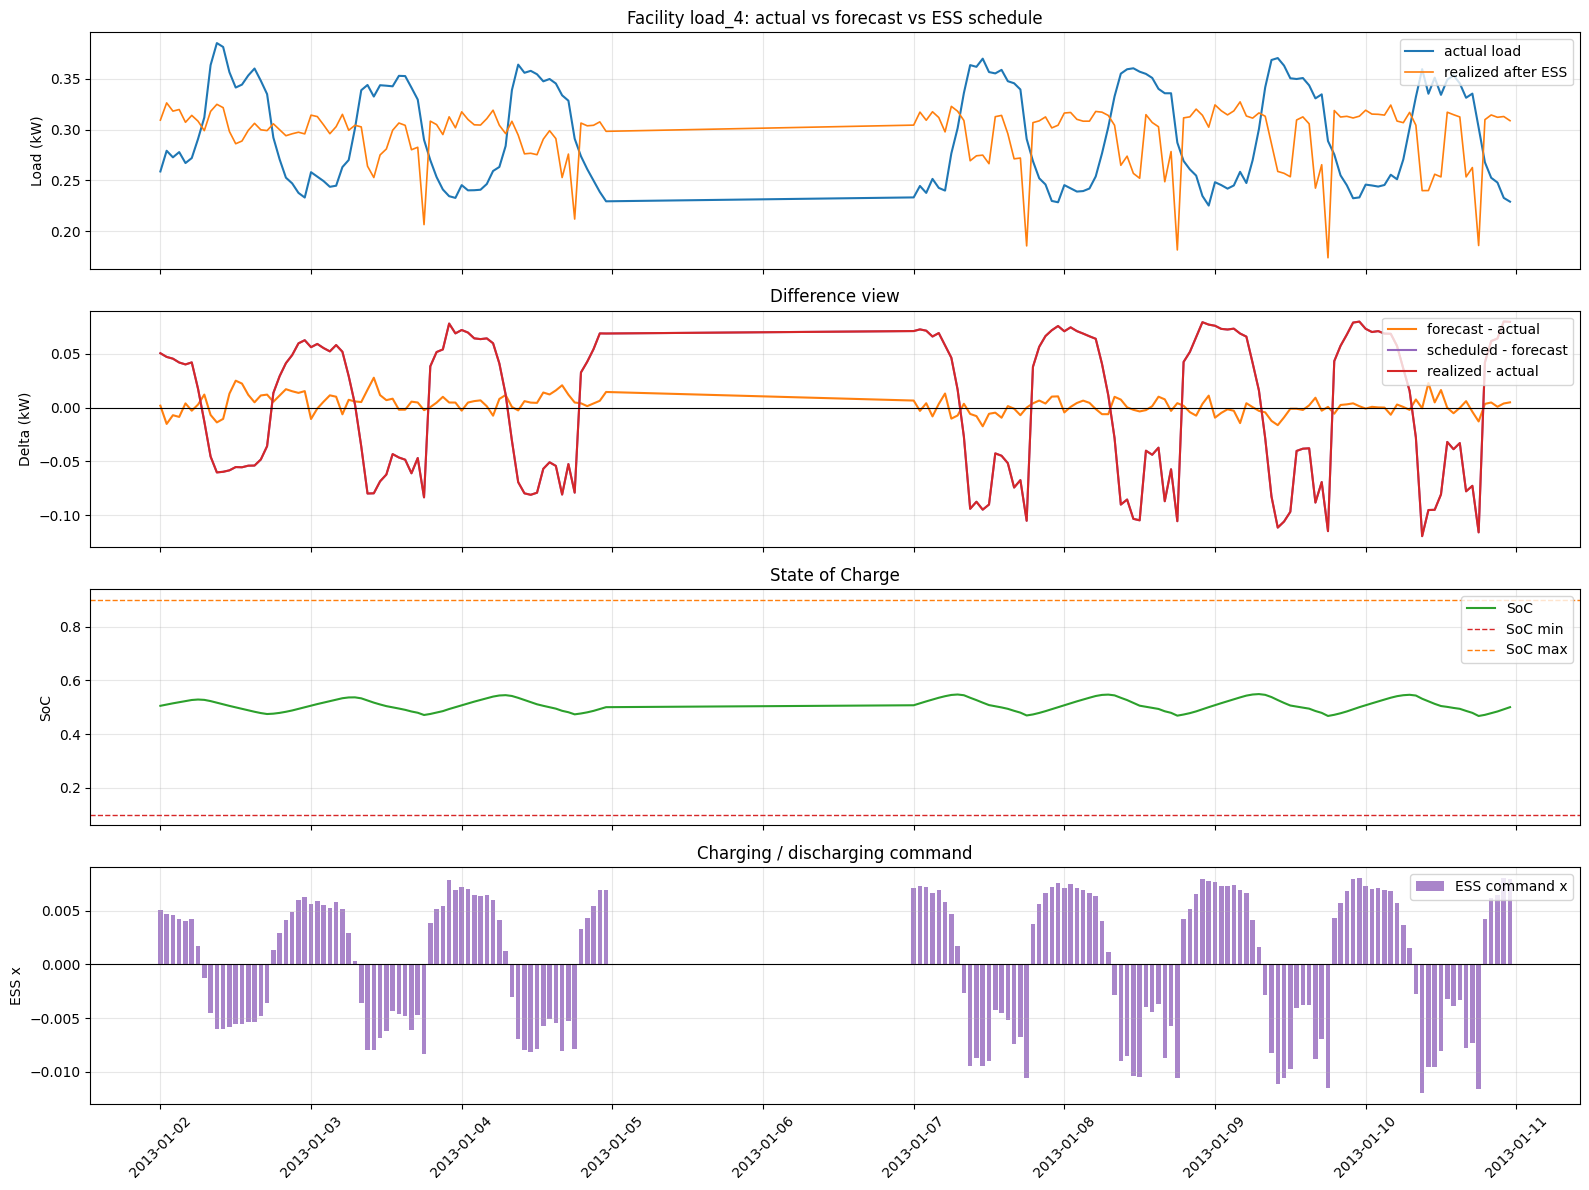

,timestamp,facility_id,real,pred_24_step,schedule,result,soc,x,ess_adjustment_kW
0,2013-01-02 00:00:00,4,0.25884,0.260590,0.311162,0.309412,0.505057,0.005057,0.050572
1,2013-01-02 01:00:00,4,0.27924,0.264012,0.311162,0.326390,0.509772,0.004715,0.047150
2,2013-01-02 02:00:00,4,0.27276,0.265652,0.311162,0.318270,0.514323,0.004551,0.045510
3,2013-01-02 03:00:00,4,0.27792,0.269222,0.311162,0.319860,0.518517,0.004194,0.041940
4,2013-01-02 04:00:00,4,0.26712,0.271007,0.311162,0.307275,0.522533,0.004016,0.040155


In [15]:
VIS_FACILITY_ID = 4
VIS_START_ROW = 0
VIS_HOURS = 24 * 7

vis_path = RESULT_DIR / f"load_{VIS_FACILITY_ID}_schedule.csv"
if not vis_path.exists():
    raise FileNotFoundError(f"시각화할 결과 파일이 없습니다: {vis_path}")

vis_df = pd.read_csv(vis_path, parse_dates=["timestamp"])
vis_slice = vis_df.iloc[VIS_START_ROW:VIS_START_ROW + VIS_HOURS].copy()
if vis_slice.empty:
    raise ValueError("선택한 구간에 시각화할 데이터가 없습니다.")

vis_slice["ess_adjustment_kW"] = vis_slice["schedule"] - vis_slice["pred_24_step"]
vis_slice["forecast_error_kW"] = vis_slice["pred_24_step"] - vis_slice["real"]
vis_slice["realized_adjustment_kW"] = vis_slice["result"] - vis_slice["real"]

display(pd.Series({
    "result_file": str(vis_path),
    "rows_in_file": len(vis_df),
    "rows_plotted": len(vis_slice),
    "start": vis_slice["timestamp"].min(),
    "end": vis_slice["timestamp"].max(),
    "operating_days": vis_slice["timestamp"].dt.date.nunique(),
    "max_abs_ess_adjustment_kW": vis_slice["ess_adjustment_kW"].abs().max(),
    "mean_abs_ess_adjustment_kW": vis_slice["ess_adjustment_kW"].abs().mean(),
}))

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(vis_slice["timestamp"], vis_slice["real"], label="actual load", linewidth=1.5)
#axes[0].plot(vis_slice["timestamp"], vis_slice["pred_24_step"], label="forecast load", linewidth=1.2)
#axes[0].plot(vis_slice["timestamp"], vis_slice["schedule"], label="scheduled load", linewidth=1.2)
axes[0].plot(vis_slice["timestamp"], vis_slice["result"], label="realized after ESS", linewidth=1.2)
axes[0].set_ylabel("Load (kW)")
axes[0].set_title(f"Facility load_{VIS_FACILITY_ID}: actual vs forecast vs ESS schedule")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

axes[1].plot(vis_slice["timestamp"], vis_slice["forecast_error_kW"], label="forecast - actual", color="tab:orange")
axes[1].plot(vis_slice["timestamp"], vis_slice["ess_adjustment_kW"], label="scheduled - forecast", color="tab:purple")
axes[1].plot(vis_slice["timestamp"], vis_slice["realized_adjustment_kW"], label="realized - actual", color="tab:red")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Delta (kW)")
axes[1].set_title("Difference view")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

axes[2].plot(vis_slice["timestamp"], vis_slice["soc"], color="tab:green", label="SoC")
axes[2].axhline(soc_min, color="tab:red", linestyle="--", linewidth=1.0, label="SoC min")
axes[2].axhline(soc_max, color="tab:orange", linestyle="--", linewidth=1.0, label="SoC max")
axes[2].set_ylabel("SoC")
axes[2].set_title("State of Charge")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)

axes[3].bar(vis_slice["timestamp"], vis_slice["x"], width=0.03, color="tab:purple", alpha=0.8, label="ESS command x")
axes[3].axhline(0, color="black", linewidth=0.8)
axes[3].set_ylabel("ESS x")
axes[3].set_title("Charging / discharging command")
axes[3].legend(loc="upper right")
axes[3].grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

vis_slice[["timestamp", "facility_id", "real", "pred_24_step", "schedule", "result", "soc", "x", "ess_adjustment_kW"]].head()
